# Fraud Detection Data Analysis
### Completed Assignment — Tasks 1 to 5

**Dataset:** Fraud Detection Dataset



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

sns.set_theme(style="whitegrid")

# Load the supplied fraud detection dataset
df_raw = pd.read_csv("Fraud Detection Dataset(2).csv")

print("Original dataset shape:", df_raw.shape)
display(df_raw.head())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-r2zo2zix because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Original dataset shape: (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [2]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

Columns:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']

Data types:


,dtype
Transaction_ID,object
User_ID,int64
Transaction_Amount,float64
Transaction_Type,object
Time_of_Transaction,float64
Device_Used,object
Location,object
Previous_Fraudulent_Transactions,int64
Account_Age,int64
Number_of_Transactions_Last_24H,int64


In [3]:
# Missing-value analysis must be performed BEFORE dropping missing rows.
missing_count = df_raw.isnull().sum()
missing_percent = (df_raw.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
}).sort_values("Missing Count", ascending=False)

display(missing_summary)

# Follow the original notebook's preprocessing step.
df = df_raw.dropna().copy()

print("Shape after dropping rows containing missing values:", df.shape)

,Missing Count,Missing Percentage
Time_of_Transaction,2552,5.00
Location,2547,4.99
Transaction_Amount,2520,4.94
Device_Used,2473,4.85
Payment_Method,2469,4.84
Transaction_Type,0,0.00
Transaction_ID,0,0.00
User_ID,0,0.00
Previous_Fraudulent_Transactions,0,0.00
Account_Age,0,0.00


Shape after dropping rows containing missing values: (39583, 12)


## Task 1: Column-wise Duplicate Count



In [4]:
column_duplicate_counts = pd.DataFrame({
    "Column": df.columns,
    "Duplicate Count": [df[col].duplicated().sum() for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns]
}).sort_values("Duplicate Count", ascending=False)

display(column_duplicate_counts)

print("Complete duplicate rows:", df.duplicated().sum())

,Column,Duplicate Count,Unique Values
11,Fraudulent,39581,2
5,Device_Used,39579,4
3,Transaction_Type,39578,5
10,Payment_Method,39578,5
7,Previous_Fraudulent_Transactions,39578,5
6,Location,39575,8
9,Number_of_Transactions_Last_24H,39569,14
4,Time_of_Transaction,39559,24
8,Account_Age,39464,119
1,User_ID,35583,4000


Complete duplicate rows: 688


## Task 2: Cluster for Payment_Method vs Fraudulent



Fraudulent,0,1,All
Payment_Method,,,
Credit Card,9009,460,9469
Debit Card,9167,456,9623
Invalid Method,1174,56,1230
Net Banking,9029,474,9503
UPI,9272,486,9758
All,37651,1932,39583


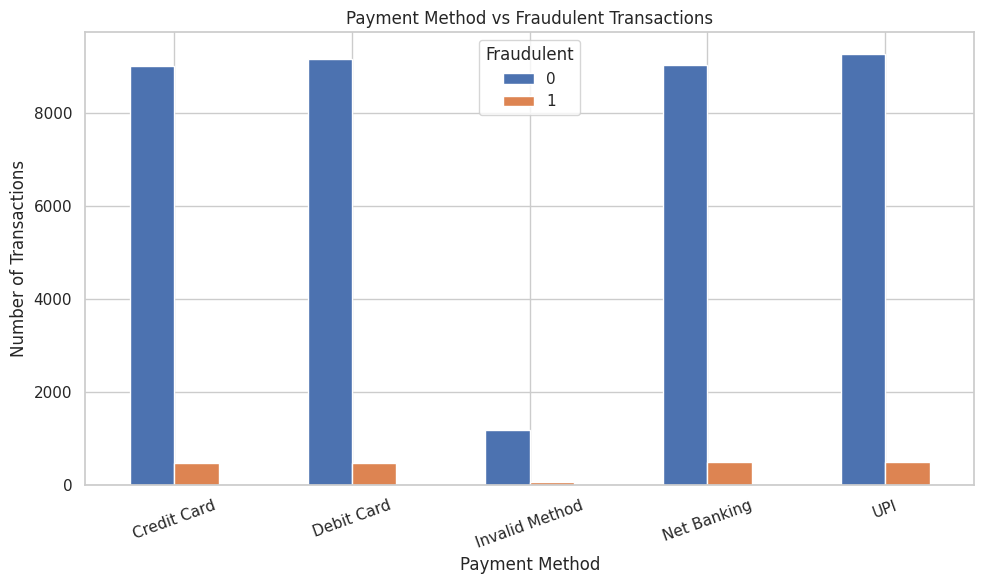

,Fraud Rate (%)
Payment_Method,
Net Banking,4.99
UPI,4.98
Credit Card,4.86
Debit Card,4.74
Invalid Method,4.55


In [5]:
payment_fraud_table = pd.crosstab(
    df["Payment_Method"],
    df["Fraudulent"],
    margins=True
)

display(payment_fraud_table)

plot_table = pd.crosstab(df["Payment_Method"], df["Fraudulent"])
ax = plot_table.plot(kind="bar", figsize=(10, 6))
ax.set_title("Payment Method vs Fraudulent Transactions")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

payment_fraud_rate = (
    df.groupby("Payment_Method")["Fraudulent"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
      .rename("Fraud Rate (%)")
)

display(payment_fraud_rate.to_frame())

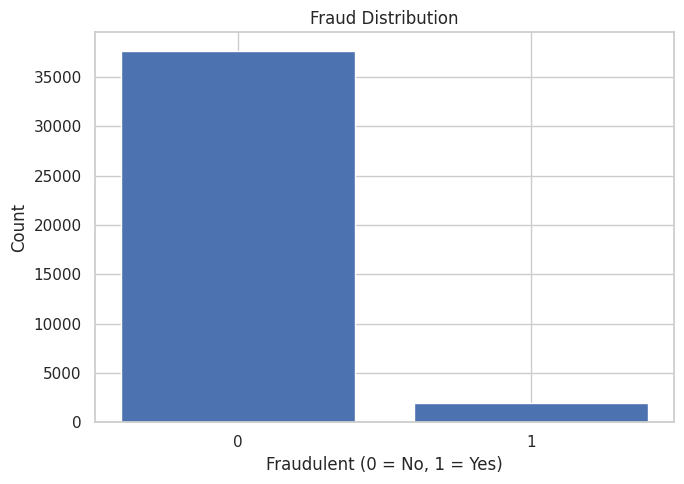

In [6]:
# Overall fraud distribution
fraud_counts = df["Fraudulent"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(fraud_counts.index.astype(str), fraud_counts.values)
plt.title("Fraud Distribution")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

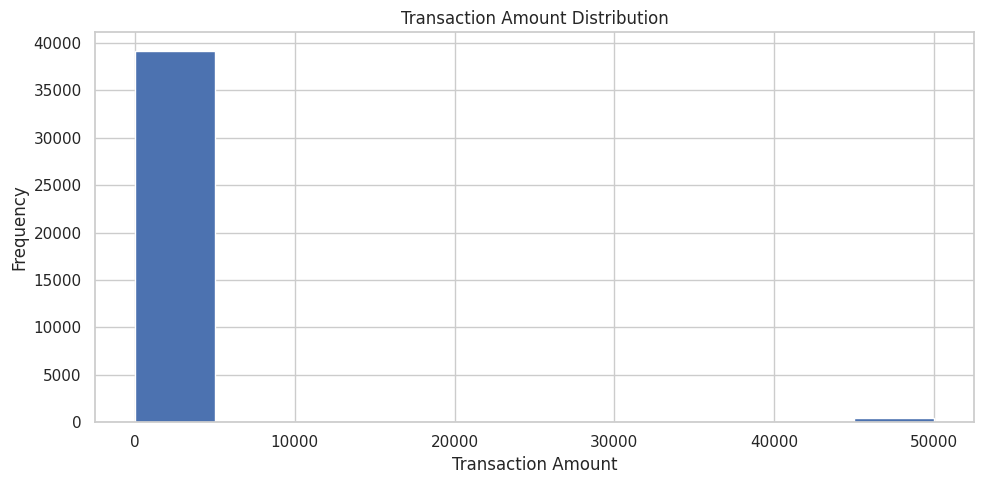

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(df["Transaction_Amount"], bins=10)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Outlier Analysis: Transaction_Amount



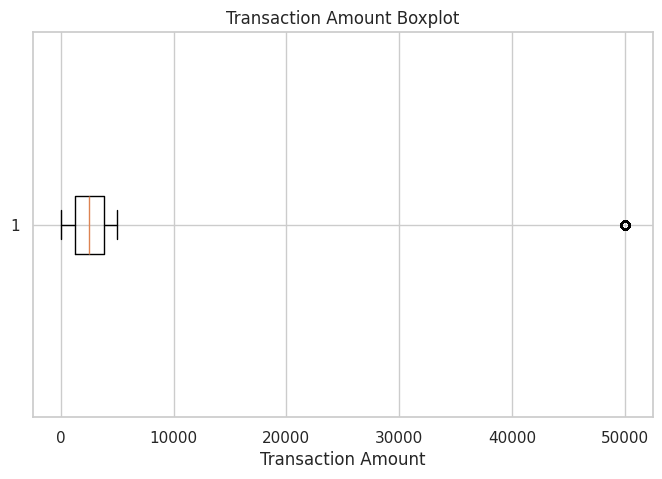

Q1 = 1267.43
Q3 = 3781.08
IQR = 2513.64
Lower bound = -2503.03
Upper bound = 7551.55
Transaction amount outlier records: 416


In [8]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Transaction_Amount"], vert=False)
plt.title("Transaction Amount Boxplot")
plt.xlabel("Transaction Amount")
plt.show()

Q1 = df["Transaction_Amount"].quantile(0.25)
Q3 = df["Transaction_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

amount_outliers = df[
    (df["Transaction_Amount"] < lower) |
    (df["Transaction_Amount"] > upper)
]

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Lower bound = {lower:.2f}")
print(f"Upper bound = {upper:.2f}")
print("Transaction amount outlier records:", len(amount_outliers))

## Task 2 (continued): Find Outliers from Time_of_Transaction and Create Graph



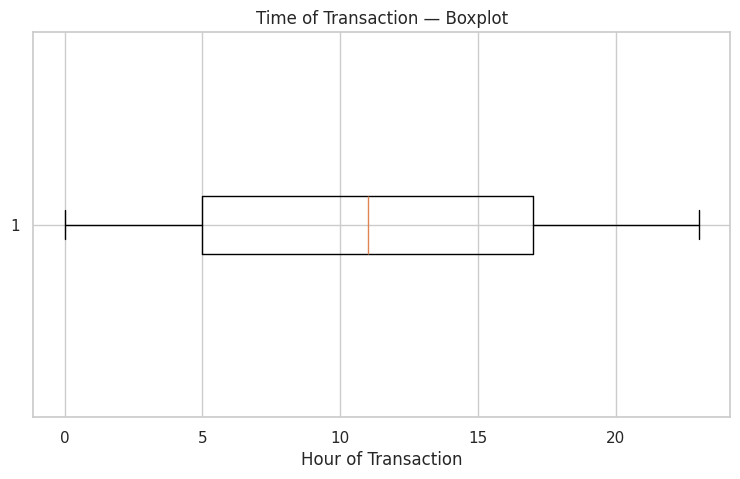

Q1 = 5.00
Q3 = 17.00
IQR = 12.00
IQR lower bound = -13.00
IQR upper bound = 35.00
Time outlier records by IQR: 0
Valid hour range in data: 0 to 23


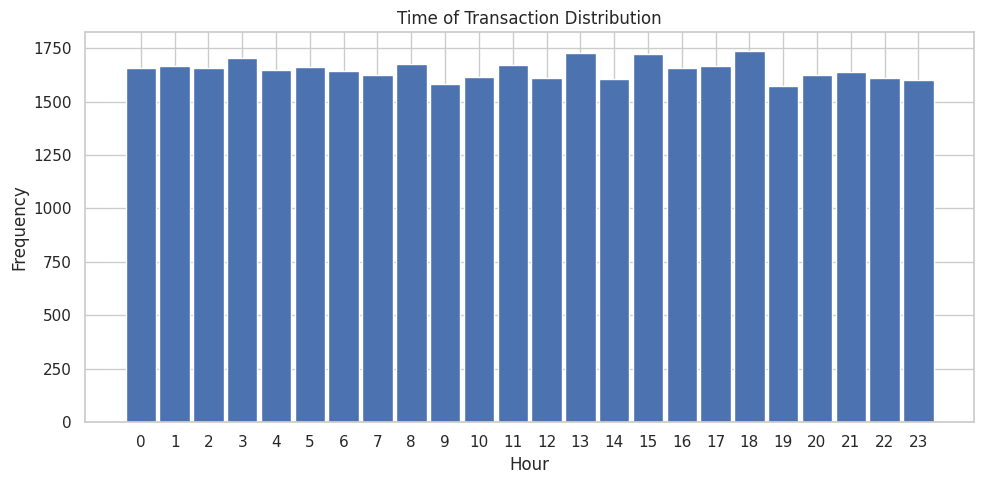

In [9]:
plt.figure(figsize=(9, 5))
plt.boxplot(df["Time_of_Transaction"], vert=False)
plt.title("Time of Transaction — Boxplot")
plt.xlabel("Hour of Transaction")
plt.show()

Q1_time = df["Time_of_Transaction"].quantile(0.25)
Q3_time = df["Time_of_Transaction"].quantile(0.75)
IQR_time = Q3_time - Q1_time
lower_time = Q1_time - 1.5 * IQR_time
upper_time = Q3_time + 1.5 * IQR_time

time_outliers = df[
    (df["Time_of_Transaction"] < lower_time) |
    (df["Time_of_Transaction"] > upper_time)
]

print(f"Q1 = {Q1_time:.2f}")
print(f"Q3 = {Q3_time:.2f}")
print(f"IQR = {IQR_time:.2f}")
print(f"IQR lower bound = {lower_time:.2f}")
print(f"IQR upper bound = {upper_time:.2f}")
print("Time outlier records by IQR:", len(time_outliers))
print("Valid hour range in data:", int(df["Time_of_Transaction"].min()), "to", int(df["Time_of_Transaction"].max()))

plt.figure(figsize=(10, 5))
plt.hist(df["Time_of_Transaction"], bins=np.arange(-0.5, 24.5, 1), rwidth=0.9)
plt.title("Time of Transaction Distribution")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## Task 3: Identify Uncommon or Common Values



In [10]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]

for feature in features:
    counts = df[feature].value_counts()

    print(f"\n{'='*70}")
    print(f"Feature: {feature}")
    print("Common values (top 5):")
    display(counts.head(5).rename("Frequency").to_frame())

    print("Uncommon values (bottom 5):")
    display(counts.sort_values(ascending=True).head(5).rename("Frequency").to_frame())

print("\nCategorical feature frequency summaries:")
for feature in ["Transaction_Type", "Device_Used", "Location", "Payment_Method"]:
    print(f"\n{feature}")
    display(df[feature].value_counts().rename("Frequency").to_frame())


Feature: Transaction_Amount
Common values (top 5):


,Frequency
Transaction_Amount,
49997.80,416
2092.21,4
3562.91,4
1747.31,4
1762.20,3


Uncommon values (bottom 5):


,Frequency
Transaction_Amount,
3569.79,1
2730.54,1
1135.18,1
4107.70,1
219.27,1



Feature: Previous_Fraudulent_Transactions
Common values (top 5):


...

,Frequency
Device_Used,
Desktop,12835
Tablet,12777
Mobile,12734
Unknown Device,1237



Location


,Frequency
Location,
Boston,5045
Seattle,4997
New York,4963
Los Angeles,4945
Chicago,4933
San Francisco,4928
Miami,4895
Houston,4877



Payment_Method


,Frequency
Payment_Method,
UPI,9758
Debit Card,9623
Net Banking,9503
Credit Card,9469
Invalid Method,1230


### DBSCAN clustering for Task 3



In [11]:
cluster_features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]

X = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)
df["Cluster"] = labels

print("Cluster counts:")
display(df["Cluster"].value_counts().sort_index())

print("Number of DBSCAN noise/anomaly records (Cluster = -1):", (df["Cluster"] == -1).sum())

Cluster counts:


Cluster
-1        8
 0    39167
 1      408
Name: count, dtype: int64

Number of DBSCAN noise/anomaly records (Cluster = -1): 8


## Task 4: Identify Anomalies with -1 



In [12]:
different_features = [
    "Time_of_Transaction",
    "Transaction_Amount",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]

X2 = df[different_features]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

dbscan2 = DBSCAN(
    eps=0.6,
    min_samples=15
)

labels2 = dbscan2.fit_predict(X2_scaled)
df["Cluster_Task4"] = labels2

print("Task 4 cluster counts:")
display(df["Cluster_Task4"].value_counts().sort_index())

suspicious = df[df["Cluster_Task4"] == -1].copy()

print("Number of anomalies (Cluster_Task4 = -1):", len(suspicious))
display(suspicious.head(10))

Task 4 cluster counts:


Cluster_Task4
-1      300
 0    39167
 1       29
 2       56
 3       15
 4       16
Name: count, dtype: int64

Number of anomalies (Cluster_Task4 = -1): 300


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Cluster,Cluster_Task4
245,T246,2306,49997.8,Bill Payment,1.0,Desktop,New York,3,78,9,UPI,0,1,-1
298,T299,2153,49997.8,Online Purchase,18.0,Tablet,San Francisco,2,85,2,Net Banking,0,1,-1
317,T318,4681,49997.8,Bill Payment,0.0,Mobile,Houston,4,4,14,Credit Card,0,-1,-1
551,T552,2982,49997.8,Bill Payment,17.0,Tablet,Chicago,3,37,7,Invalid Method,1,1,-1
561,T562,3617,49997.8,Bill Payment,14.0,Tablet,Chicago,3,10,3,Credit Card,0,1,-1
773,T774,3914,49997.8,Bill Payment,21.0,Desktop,San Francisco,3,6,12,UPI,0,1,-1
790,T791,4304,49997.8,POS Payment,19.0,Mobile,San Francisco,1,103,5,Invalid Method,0,1,-1
1282,T1283,2305,49997.8,Bill Payment,1.0,Mobile,Seattle,3,72,12,UPI,0,1,-1
1553,T1554,4051,49997.8,Online Purchase,0.0,Mobile,San Francisco,0,55,11,UPI,0,1,-1
1574,T1575,4797,49997.8,Online Purchase,3.0,Desktop,Houston,2,57,8,Net Banking,0,1,-1


## Task 5: Create Graphs for Anomalies



### Task 5: Cluster Graph (any two attributes)

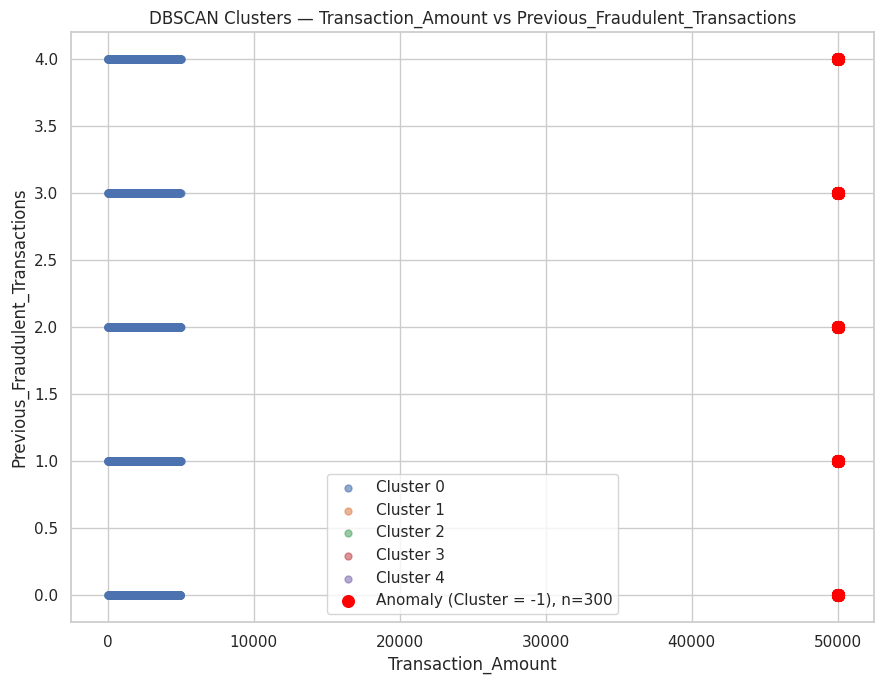

In [13]:
x_attr = "Transaction_Amount"
y_attr = "Previous_Fraudulent_Transactions"

non_noise = df[df["Cluster_Task4"] != -1]
noise = df[df["Cluster_Task4"] == -1]

sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

plt.figure(figsize=(9, 7))

for cluster_id, group in plot_sample.groupby("Cluster_Task4"):
    plt.scatter(
        group[x_attr], group[y_attr],
        s=25, alpha=0.6, label=f"Cluster {cluster_id}"
    )

plt.scatter(
    noise[x_attr],
    noise[y_attr],
    c="red",
    marker="o",
    s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title(f"DBSCAN Clusters — {x_attr} vs {y_attr}")
plt.legend()
plt.tight_layout()
plt.show()

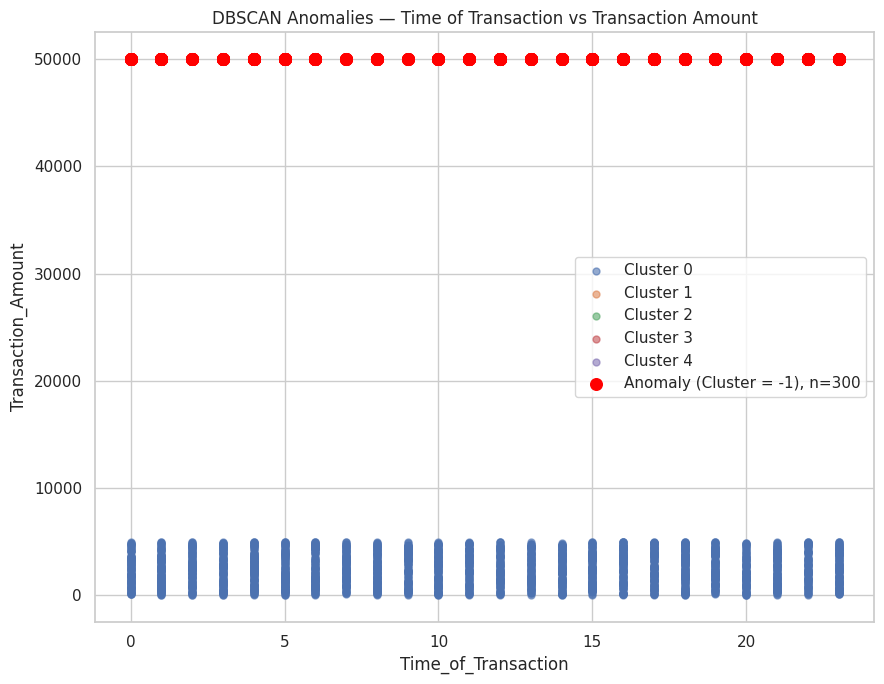

In [14]:
plt.figure(figsize=(9, 7))

for cluster_id, group in plot_sample.groupby("Cluster_Task4"):
    plt.scatter(
        group["Time_of_Transaction"], group["Transaction_Amount"],
        s=25, alpha=0.6, label=f"Cluster {cluster_id}"
    )

plt.scatter(
    noise["Time_of_Transaction"],
    noise["Transaction_Amount"],
    c="red",
    marker="o",
    s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel("Time_of_Transaction")
plt.ylabel("Transaction_Amount")
plt.title("DBSCAN Anomalies — Time of Transaction vs Transaction Amount")
plt.legend()
plt.tight_layout()
plt.show()